# Phase 7: TCAV

Phase 7 moves from concept descriptions to concept sensitivity.

This notebook runs the TCAV pipeline implemented in `src/tcav.py` and `scripts/run_phase7_tcav.py`:

- select positive and negative AwA2 examples for each semantic concept;
- extract pooled activations from an internal ResNet layer;
- train one Concept Activation Vector per concept;
- compute whether the concept direction increases target class scores;
- save CSV reports and visual summaries.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import csv
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

CANDIDATE_MANIFESTS = [
    PROJECT_ROOT / 'data' / 'AWA2_subset_background20' / 'awa2_manifest_subset.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest_debug.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest.csv',
]
MANIFEST = next((path for path in CANDIDATE_MANIFESTS if path.exists()), None)
if MANIFEST is None:
    raise FileNotFoundError('No AwA2 manifest found.')

METADATA_ROOT = PROJECT_ROOT / 'data' / 'AWA2'
CHECKPOINT = PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_resnet50_awa2.pt'

CONCEPTS = ['stripes', 'furry', 'hooves', 'horns', 'flippers']
TARGET_CLASSES = []  # leave empty to let the script choose compact concept-relevant targets

SCORE_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase7_tcav_scores_notebook.csv'
CAV_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase7_cav_summary_notebook.csv'
HEATMAP_OUTPUT = PROJECT_ROOT / 'outputs' / 'figures' / 'phase7_tcav_heatmap_notebook.png'
BAR_OUTPUT = PROJECT_ROOT / 'outputs' / 'figures' / 'phase7_tcav_top_scores_notebook.png'

print('manifest:', MANIFEST)
print('metadata_root:', METADATA_ROOT)
print('checkpoint:', CHECKPOINT, 'exists=', CHECKPOINT.exists())
print('concepts:', CONCEPTS)
print('target_classes:', TARGET_CLASSES or 'auto')


manifest: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
metadata_root: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2
checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt exists= True
concepts: ['stripes', 'furry', 'hooves', 'horns', 'flippers']
target_classes: auto


## Run TCAV

This cell trains CAVs for the selected concepts and computes class-level TCAV scores. The default layer is `layer3`: it is still high-level, but unlike the final `layer4` output it keeps a non-linear part of ResNet downstream, so TCAV scores do not collapse to class-level constants.


In [2]:
cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'scripts' / 'run_phase7_tcav.py'),
    '--manifest', str(MANIFEST),
    '--metadata-root', str(METADATA_ROOT),
    '--checkpoint', str(CHECKPOINT),
    '--concepts', *CONCEPTS,
    '--layer', 'layer3',
    '--score-output', str(SCORE_CSV),
    '--cav-output', str(CAV_CSV),
    '--heatmap-output', str(HEATMAP_OUTPUT),
    '--bar-output', str(BAR_OUTPUT),
    '--max-target-classes', '10',
    '--max-concept-examples', '200',
    '--max-eval-per-class', '40',
]
if TARGET_CLASSES:
    cmd.extend(['--target-classes', *TARGET_CLASSES])

print(' '.join(cmd))
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()


/home/emma/DeepLearning/.venvDeepLearning/bin/python /home/emma/DeepLearning/Deep_Learning_XAI/scripts/run_phase7_tcav.py --manifest /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv --metadata-root /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2 --checkpoint /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt --concepts stripes furry hooves horns flippers --layer layer3 --score-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase7_tcav_scores_notebook.csv --cav-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase7_cav_summary_notebook.csv --heatmap-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase7_tcav_heatmap_notebook.png --bar-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase7_tcav_top_scores_notebook.png --max-target-classes 10 --max-concept-examples 200 --max-eval-per-class 40



2026-07-10 14:55:01 | INFO | run_phase7_tcav | manifest=/home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
2026-07-10 14:55:01 | INFO | run_phase7_tcav | checkpoint=/home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt
2026-07-10 14:55:01 | INFO | run_phase7_tcav | num_classes=20 device=cpu
2026-07-10 14:55:01 | INFO | run_phase7_tcav | metadata_root=/home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2/Animals_with_Attributes2
2026-07-10 14:55:01 | INFO | src.data | Loaded manifest split=train with 2782 samples, 20 visible classes, 20 mapped classes from /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
2026-07-10 14:55:01 | INFO | src.data | Loaded manifest split=val with 596 samples, 20 visible classes, 20 mapped classes from /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
2026-07-10 14:55:01 | INFO | src.data | Lo

## Inspect TCAV Figures

The heatmap shows the fraction of positive directional derivatives for every target class and concept. The bar plot highlights the strongest class-concept sensitivities.


/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase7_tcav_heatmap_notebook.png


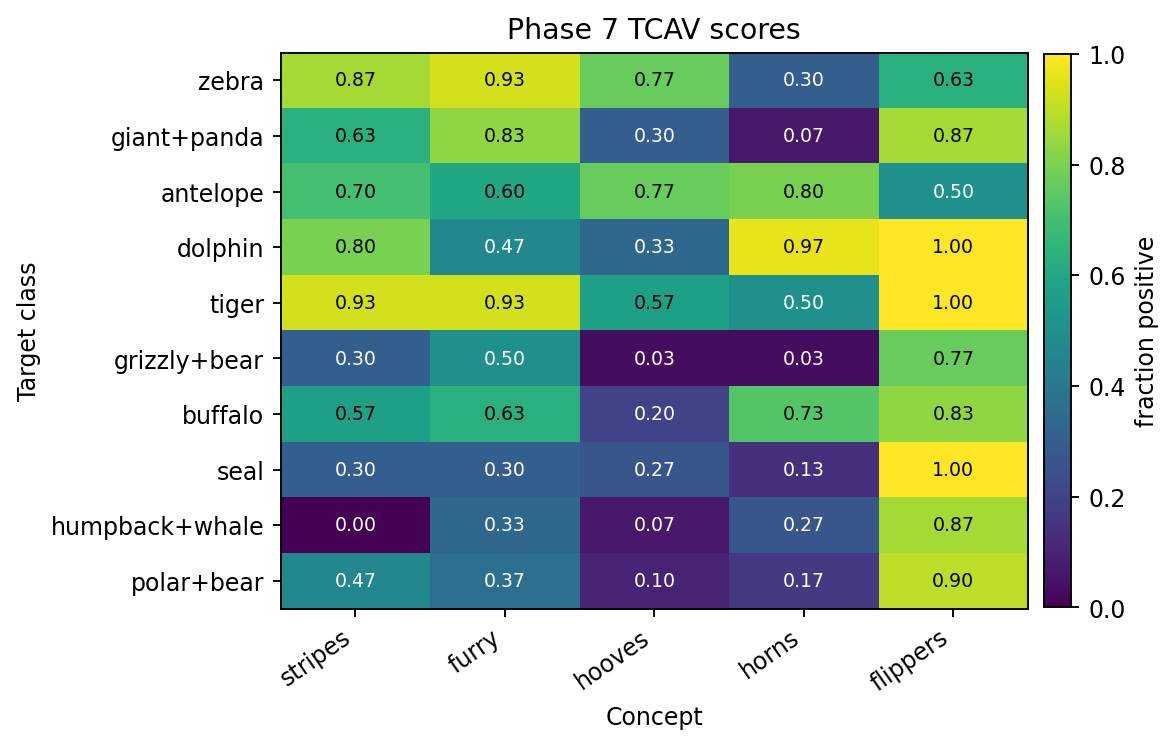

/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase7_tcav_top_scores_notebook.png


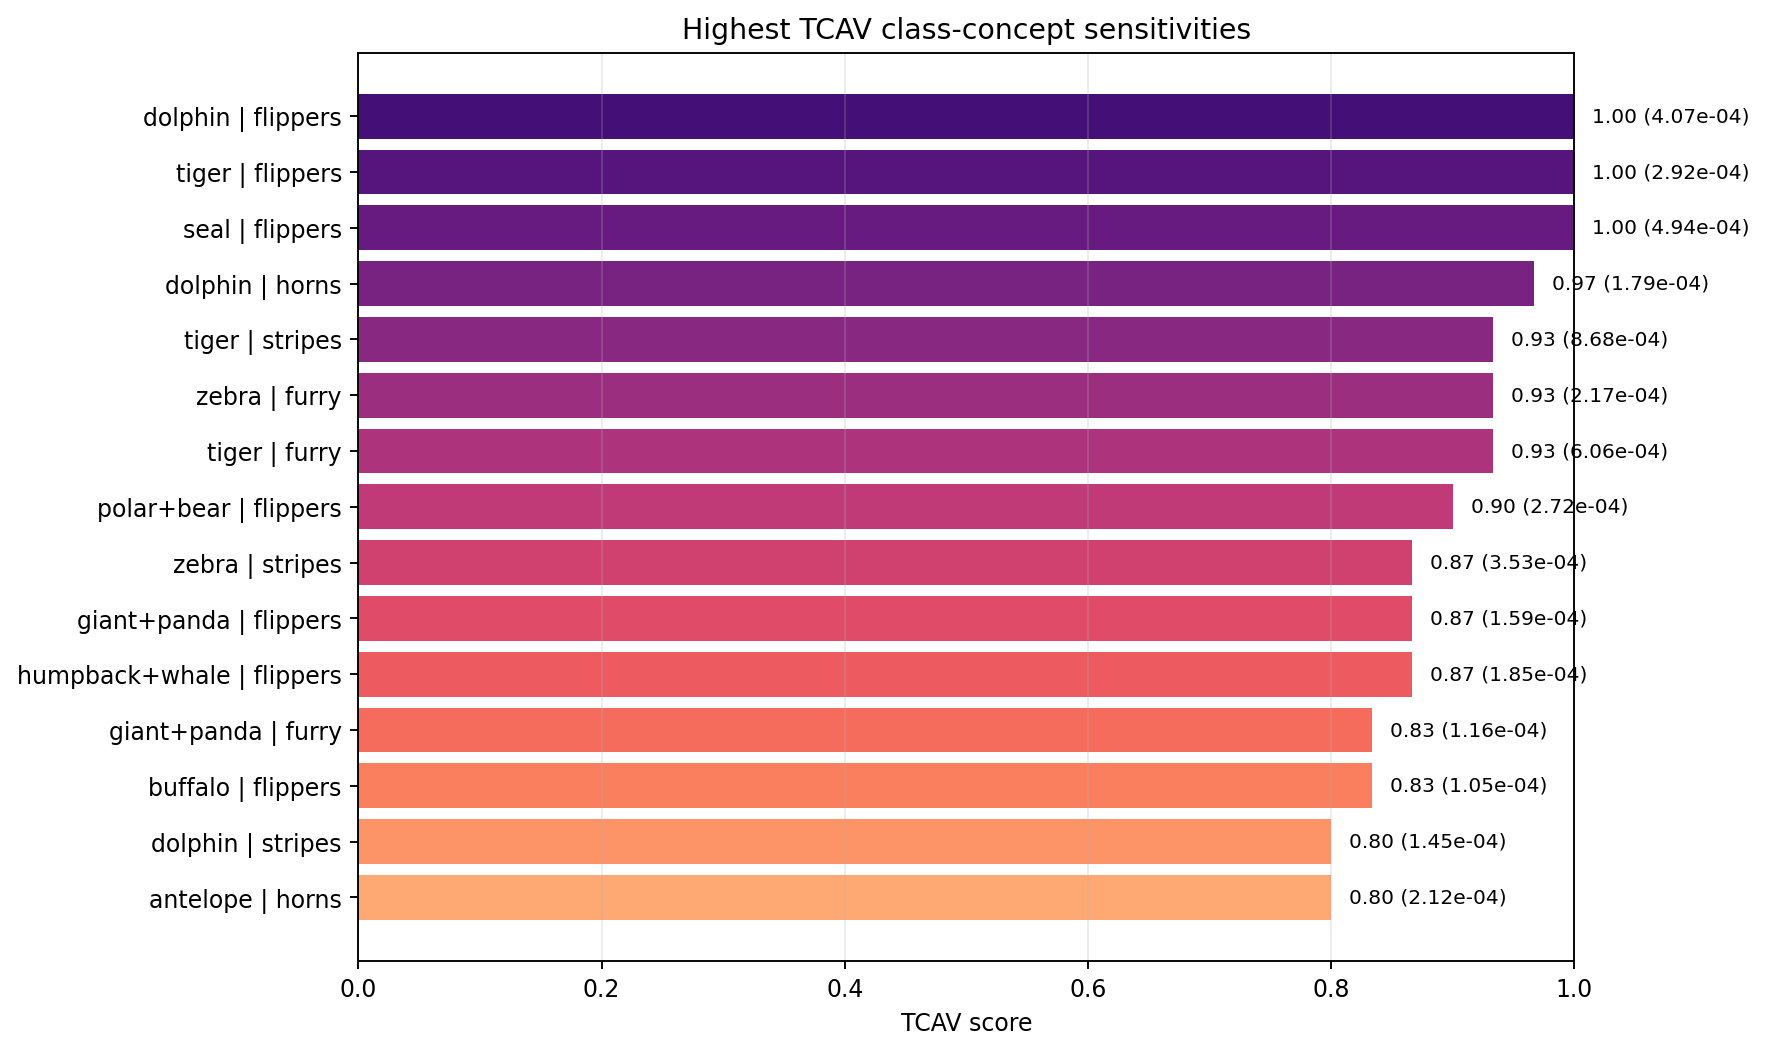

In [3]:
for figure in [HEATMAP_OUTPUT, BAR_OUTPUT]:
    print(figure)
    if figure.exists():
        display(Image(filename=str(figure)))
    else:
        print('missing figure:', figure)


## Inspect CSV Reports

`phase7_cav_summary` describes how each CAV was trained. `phase7_tcav_scores` contains the class-concept sensitivity scores used by the figures.


In [4]:
for csv_path in [CAV_CSV, SCORE_CSV]:
    print('\n', csv_path)
    if not csv_path.exists():
        print('missing csv')
        continue
    with csv_path.open('r', newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    print('rows:', len(rows))
    for row in rows[:8]:
        print(row)



 /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase7_cav_summary_notebook.csv
rows: 5
{'concept': 'stripes', 'layer': 'layer3', 'pool': 'avg', 'positive_count': '200', 'negative_count': '200', 'positive_threshold': '0.75', 'negative_threshold': '0.25', 'cav_train_accuracy': '1.0', 'cav_final_loss': '0.0006015049293637276', 'positive_classes': 'zebra:108; tiger:92', 'negative_classes': 'sheep:18; leopard:14; bobcat:14; buffalo:14; elephant:13; hippopotamus:12; walrus:11; blue+whale:11'}
{'concept': 'furry', 'layer': 'layer3', 'pool': 'avg', 'positive_count': '200', 'negative_count': '200', 'positive_threshold': '0.75', 'negative_threshold': '0.25', 'cav_train_accuracy': '1.0', 'cav_final_loss': '0.0008934754296205938', 'positive_classes': 'wolf:33; lion:32; grizzly+bear:32; tiger:29; giant+panda:28; polar+bear:26; bobcat:20', 'negative_classes': 'seal:29; dolphin:27; giraffe:26; blue+whale:26; humpback+whale:26; elephant:25; walrus:25; hippopotamus:16'}
{'concept': 'hooves

## Reading the Scores

A high TCAV score means that the target class logit often increases along that concept direction in activation space. A low score means the class score is not consistently sensitive to that concept. This complements Phase 6: the previous phase tells us which concepts describe classes, while TCAV asks whether the trained model's internal representation is directionally sensitive to those concepts.
